In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
try:
    df = pd.read_csv('../data/raw_analyst_ratings.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please check if 'raw_analyst_ratings.csv' is in the 'data' folder.")

Data loaded successfully!


In [4]:
# Display the first 5 rows of the data
display(df.head())

# Display the structure of the data (columns, missing values, types)
print("\nData Info:")
print(df.info())

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB
None


In [5]:
# 1. Check how big the data is
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# 2. Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

Total Rows: 1407328
Total Columns: 6

Missing Values per Column:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


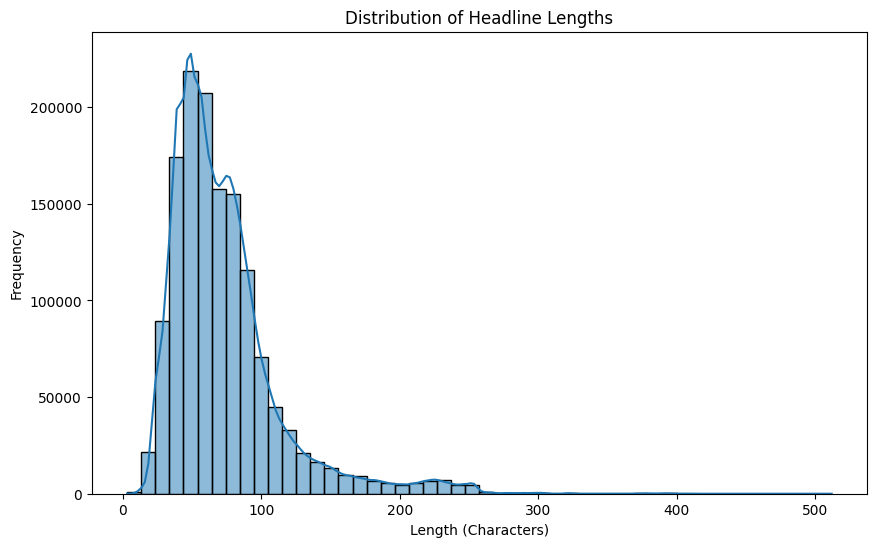

In [8]:
# Create a new column for the length of each headline
df['headline_len'] = df['headline'].apply(len)

# Get the basic stats (Mean, Max, Min)
print("Headline Length Statistics:")
print(df['headline_len'].describe())

# VISUALIZATION: Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Length (Characters)')
plt.ylabel('Frequency')
plt.show()


Top 10 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


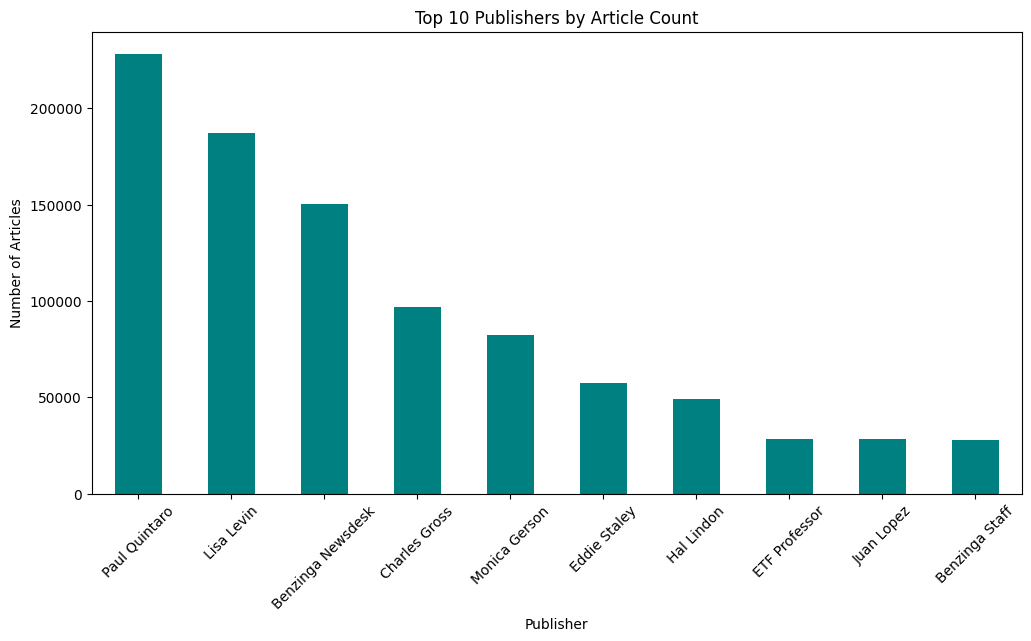

In [9]:
# Count how many articles each publisher has
publisher_counts = df['publisher'].value_counts()

# Print the top 10
print("Top 10 Publishers:")
print(publisher_counts.head(10))

# VISUALIZATION: Bar Chart of Top 10
plt.figure(figsize=(12, 6))
publisher_counts.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Publishers by Article Count')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

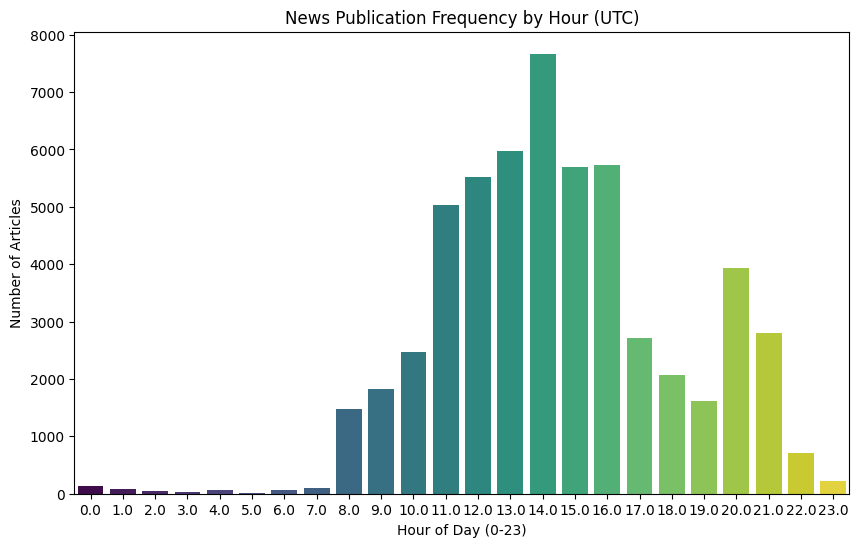

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=df, hue='hour', palette='viridis', legend=False)
plt.title('News Publication Frequency by Hour (UTC)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Articles')
plt.show()
